In [ ]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_save_images = '/home/gterren/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list

tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')

# Load and processing system load timepoints

In [3]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint          load_zone   static_load  net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  20069.969633 -7885.524559             0.0   
1  2040040101  Arunachal_Pradesh    159.9

In [4]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

# State-level metrics for all interations

In [ ]:
metrics = []
all_zones = df_load_['load_zone'].unique()

for zone in all_zones:
    dfz = df_load_[df_load_['load_zone'] == zone].copy()
    dfz['is_lol']     = dfz['unserved_energy'] > 0
    dfz['date']       = dfz['timestamp'].dt.date
    dfz['hrs_in_tmp'] = 1

    # 1) how many distinct W/H/A runs?
    num_iters = dfz[['W','H','A']].drop_duplicates().shape[0]

    # 2) hours in one run (should be 8760)
    first_run = dfz[
        (dfz['W'] == dfz['W'].iloc[0]) &
        (dfz['H'] == dfz['H'].iloc[0]) &
        (dfz['A'] == dfz['A'].iloc[0])
    ]
    hrs_per_combo = first_run['hrs_in_tmp'].sum()

    # 3) total “years” simulated
    n_years = (num_iters * hrs_per_combo) / 8760
    # print(n_years)
    # print(num_iters)
    # print(hrs_per_combo)
    # raw counts across all runs
    total_lol_hours  = dfz['is_lol'].sum()
    total_unserved   = (
        dfz.loc[dfz['is_lol'], 'unserved_energy'] 
        * dfz.loc[dfz['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol    = dfz.groupby('date')['is_lol'].max().sum()
    total_system_energy = (dfz['static_load'] * dfz['hrs_in_tmp']).sum()
    
    # annualized metrics
    LOLH = total_lol_hours / n_years                # hrs/year
    EUE  = total_unserved  / n_years                # MWh/year
    LOLP_day= (days_with_lol / 365) *100               # days/year
    LOLE = LOLP_day*365*10/100             # days per 10 yr
    # corrected LOLP:
    LOLP = total_lol_hours / (8760 * num_iters) *100     # fraction of hours
    # NENS as % of annual load
    annual_energy = total_system_energy / n_years
    NENS = (EUE / annual_energy * 100) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (MWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS,
        'LOLP_day (days/yr)': LOLP_day,
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

             load_zone  LOLH (hrs/yr)  EUE (MWh/yr)  LOLE (days/10yr)  \
0       Andhra_Pradesh       0.277778    378.950284              30.0   
1    Arunachal_Pradesh       0.000000      0.000000               0.0   
2                Assam       0.000000      0.000000               0.0   
3               Bhutan       0.000000      0.000000               0.0   
4                Bihar       0.000000      0.000000               0.0   
5           Chandigarh       1.055556     43.303542             140.0   
6         Chhattisgarh       0.000000      0.000000               0.0   
7   Dadra_Nagar_Haveli      20.777778   5188.052604             870.0   
8            Daman_Diu       0.611111    176.184541              60.0   
9                Delhi       0.333333    256.916081              60.0   
10                 Goa       5.055556   3127.172001             370.0   
11             Gujarat       0.388889   2768.723803              50.0   
12             Haryana       0.055556    327.919033

# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [28]:
df = df_load_.copy()
df['is_lol']     = df['unserved_energy'] > 0
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics = []
events_stats = []
group_cols = ['load_zone','W','H','A']

for (zone, w, h, a), sub in df.groupby(group_cols):
    # --- annualized metrics ---
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / 8760

    total_lol_hours = sub['is_lol'].sum()
    total_unserved  = (
        sub.loc[sub['is_lol'], 'unserved_energy'] 
        * sub.loc[sub['is_lol'], 'hrs_in_tmp']
    ).sum()
    days_with_lol = sub.groupby('date')['is_lol'].max().sum()
    total_energy  = (sub['static_load'] * sub['hrs_in_tmp']).sum()

    LOLH = total_lol_hours / n_years
    EUE  = total_unserved  / n_years
    EUE=EUE/1000
    LOLE = days_with_lol / n_years * 10
    LOLP = total_lol_hours / 8760
    annual_energy = total_energy / n_years
    NENS =100*( EUE / annual_energy ) if annual_energy>0 else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w,
        'H':                h,
        'A':                a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE,
        'LOLE (days/10yr)': LOLE,
        'LOLP':             LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp')
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    num_events       = int(durations.count())
    total_duration   = int(durations.sum())  # in hours

    events_stats.append({
        'load_zone':             zone,
        'W':                     w,
        'H':                     h,
        'A':                     a,
        'num_LOL_events':        num_events,
        'total_LOL_duration_hrs': total_duration
    })

# build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)

# print("=== Annual metrics ===")
# print(metrics_per_zone_df)

#print("\n=== LOL events & total duration ===")
print(lol_events_df)

          load_zone   W   H   A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh   1   1   1               0                       0
1    Andhra_Pradesh  10  10  10               0                       0
2    Andhra_Pradesh  11  11  11               0                       0
3    Andhra_Pradesh  12  12  12               0                       0
4    Andhra_Pradesh  13  13  13               0                       0
..              ...  ..  ..  ..             ...                     ...
625     West_Bengal   5   5   5               0                       0
626     West_Bengal   6   6   6               0                       0
627     West_Bengal   7   7   7               0                       0
628     West_Bengal   8   8   8               0                       0
629     West_Bengal   9   9   9               0                       0

[630 rows x 6 columns]


## State-level metric scatter plots

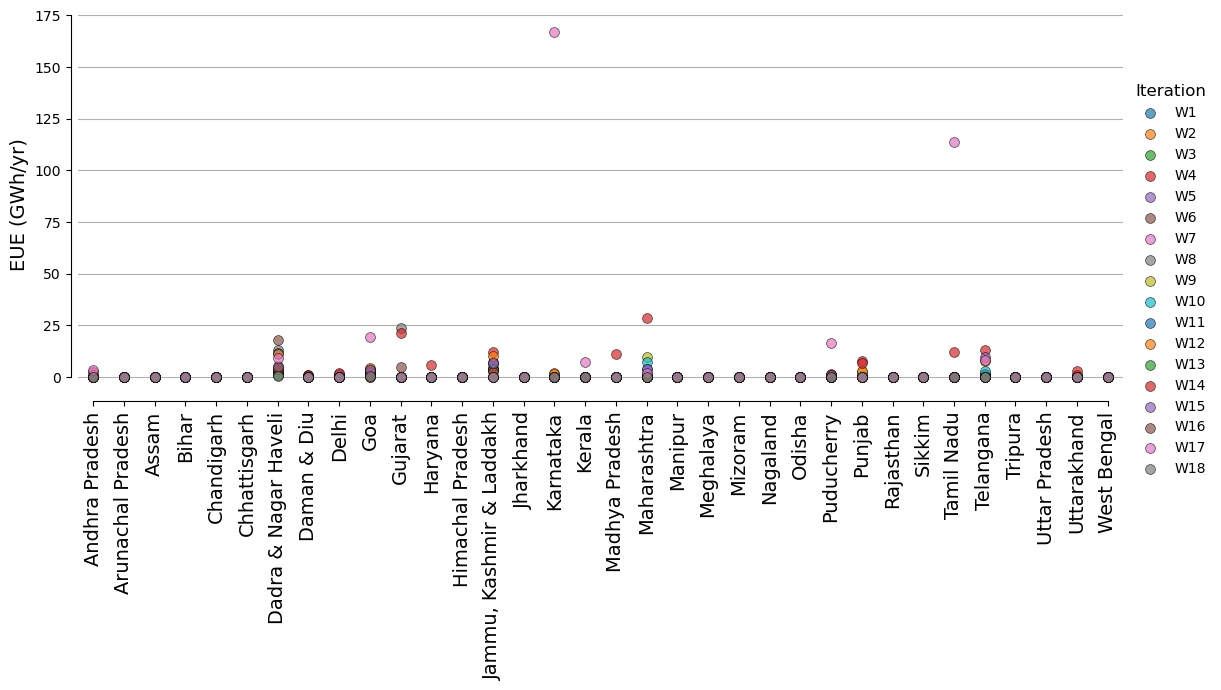

In [ ]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    grouped_data_iterable = df.groupby(list(group_cols))
    
    # Define a key for sorting the groups to ensure W1, W2, ..., W10 sequence
    def sort_key_for_groups(group_item):
        group_key = group_item[0]  # This is 'vals' from groupby
        
        if not group_cols: # Should not happen if group_cols has a default
            return group_key

        # Handle single grouping column (vals is scalar)
        if not isinstance(group_key, tuple):
            if group_cols[0] == 'W':  # Sort numerically if 'W'
                try:
                    return int(group_key)
                except ValueError:
                    return group_key  # Fallback to string sort
            return group_key
        # Handle multiple grouping columns (vals is a tuple)
        else:
            if group_cols[0] == 'W': # Sort by 'W' numerically first
                try:
                    # Create a sort key: (int(W_val), other_vals...)
                    return (int(group_key[0]),) + group_key[1:]
                except (ValueError, TypeError):
                    return group_key  # Fallback
            return group_key # Default tuple sort

    sorted_groups = []
    if group_cols:
        try:
            sorted_groups = sorted(list(grouped_data_iterable), key=sort_key_for_groups)
        except Exception: # Fallback in case of unexpected error during sorting
            sorted_groups = list(grouped_data_iterable)
    else:
        sorted_groups = list(grouped_data_iterable)


    for vals, grp in sorted_groups:  # Iterate over sorted groups
        # Corrected label generation
        current_label = ""
        if isinstance(vals, tuple):  # Multiple grouping columns
            label_parts = []
            for i, col_name in enumerate(group_cols):
                label_parts.append(f"{col_name}{vals[i]}")
            current_label = "-".join(label_parts)
        else:  # Single grouping column
            current_label = f"{group_cols[0]}{vals}"
        
        x = grp['load_zone'].map(zone_pos)
        y = grp[metric]
        
        ax.scatter(x, y, 
                   label      = current_label, 
                   s          = 50, 
                   alpha      = 0.7, 
                   edgecolors = 'black', 
                   lw         = .5, 
                   zorder     = 10)

    # set the custom ticks & labels
    ax.set_xticks(list(zone_pos.values()))

    ax.set_ylabel(metric, fontsize = 14)

    # Add a legend
    ax.legend(
        title='Iteration',
        bbox_to_anchor=(1., .85), # Position legend outside
        loc='upper left',
        fontsize=10,
        title_fontsize=12, frameon=False,
    )
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=5, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)

    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=14) 
      

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'LOLH (hrs/yr)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

fig, ax = plt.subplots(figsize = (14, 7))
plot_metrics(ax, metrics_per_zone_df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend
plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'NENS (%)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, lol_events_df, metric = 'num_LOL_events')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()


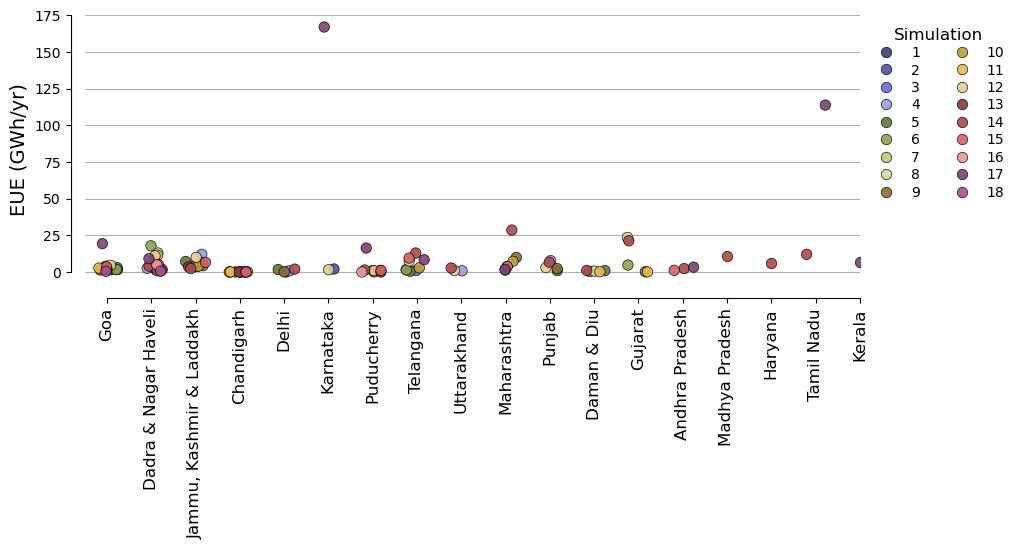

In [ ]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.] 

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones    = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    
    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])

    # for x, zone in zip(x_, zones):
    #     y = df.loc[df['load_zone'] == zone, metric].to_numpy()
    #     print(y.shape)


    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(data      = df,
                  x         = "load_zone",
                  y         = metric, 
                  size      = "s", 
                  hue       = "iteration",
                  s         = 7.5,
                  alpha     = 0.9, 
                  edgecolor = 'k',
                  linewidth        = .5,
                  zorder    = 9, 
                  jitter    = .25,
                  palette   = "tab20b")

    # set the custom ticks & labels

    ax.set_ylabel(metric, fontsize = 14)
    ax.set_xlabel('', fontsize = 14)

    # Add a legend
    ax.legend(
        title = 'Simulation',
        bbox_to_anchor = (1., 1), # Position legend outside
        #loc='upper right',
        fontsize=10, 
        labelspacing = .25,
        title_fontsize=12, 
        frameon=False, ncol = 2)
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .75)
    
    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=12) 

df = metrics_per_zone_df.copy()
df['iteration'] = df['W']
df['iteration'] = df['iteration'].astype(int)
df              = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

fig, ax = plt.subplots(figsize = (10., 3.5))
plot_metrics(ax, df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
#plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend

plt.savefig(path_to_save_images + '/zone-level_EUE.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_EUE.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()



# Loss-of-load probability heatmap

In [424]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20    2
284     12        21    0
285     12        22    0
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
1 31
2 31
2 31
0 31
1 31
1 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30

0.0 0.0 0.34050179211469533


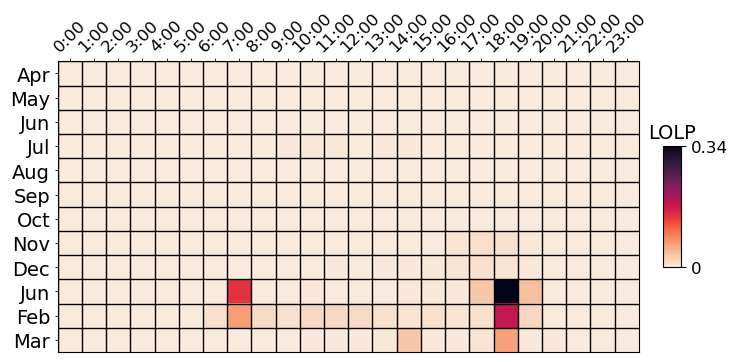

In [434]:
print(LOLP_[0, 18], LOLP_.min(), LOLP_.max())

fig, ax = plt.subplots(figsize = (7.5, 7.5))

month_    = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jun', 'Feb', 'Mar']
interval_ = [ f'{interval}:00' for interval in np.arange(24, dtype = int)]

_cmap = sns.color_palette("rocket_r", as_cmap = True)

LOLP_p = LOLP_.copy()
LOLP_p[LOLP_ == 0.] = np.nan
ax.matshow(LOLP_, 
           cmap   = _cmap, 
           vmin   = 0., 
           extent = [0, 24, 12, 0])

ax.set_yticks(range(len(month_)), []*len(month_))
ax.set_xticks(range(len(interval_)), []*len(interval_))

ax.set_yticks(np.arange(len(month_), dtype = int) + 0.5, month_, 
              rotation = 0, 
              minor    = True, 
              size     = 14)

ax.set_xticks(np.arange(len(interval_), dtype = int) + 0.5, interval_,
              rotation = 45,
              minor    = True, 
              size     = 12)

ax.tick_params(which  = 'major', 
               bottom = False, 
               left   = False, 
               top    = False)

ax.tick_params(which  = 'minor', 
               bottom = False, 
               top    = True)

ax.grid(which     = 'major', 
        color     = 'k', 
        linestyle = '-', 
        linewidth = 1.)

cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                    cax = ax.inset_axes([25, 3.5, .75, 5], transform = ax.transData), 
                    orientation = 'vertical')

cbar.set_ticks([0, 1], labels = ['0', f'{np.round(LOLP_.max(), 2)}'], size = 12)
#cbar.ax.tick_params(length = 0)
cbar.ax.set_title('LOLP', rotation = 0, size = 14)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Loss-of-load events distribution

In [398]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'W', 'H', 'A', 'load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['iteration'] = df['W'] + df['H'] + df['A']
df = df[['iteration', 'timestamp', 'load_zone', 'unserved_energy']]

df = df.sort_values(by = ['iteration', 'timestamp', 'load_zone']).reset_index(drop = True)

# Load shedding greater than 1MW
tau = 1.

df_events_ = []
for load_zone in df['load_zone'].unique():
    print(load_zone)
    for iter in df['iteration'].unique():
        idx_ = (df['iteration'] == iter) & (df['load_zone'] == load_zone)
        if idx_.sum() > 0:
            run                = df.loc[idx_].copy()
            run['is_lol']      = run['unserved_energy'] > tau
            run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
            run['event_id']    = run['event_start'].cumsum()
            #print(load_zone, iter, (run['unserved_energy'] > 0).sum(), run['is_lol'].sum())

            df_event_              = pd.DataFrame(columns = ['hours', 'load_zone', 'iteration'])
            df_event_['hours']     = run[run['is_lol']].groupby('event_id').size().to_numpy()
            df_event_['load_zone'] = load_zone
            df_event_['iteration'] = iter

            df_events_.append(df_event_)

df_events_ = pd.concat(df_events_, axis = 0).reset_index(drop = True)
print(df_events_.head())

Andhra_Pradesh
Arunachal_Pradesh
Assam
Bhutan
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Delhi
Goa
Gujarat


KeyboardInterrupt: 

[ 1  2  3  4  5  7  8 14 13] 617
[433.  26.  17.   5.   1.   0.   1.   1.   0.   0.   0.   0.   1.   2.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
(14,) (15,)


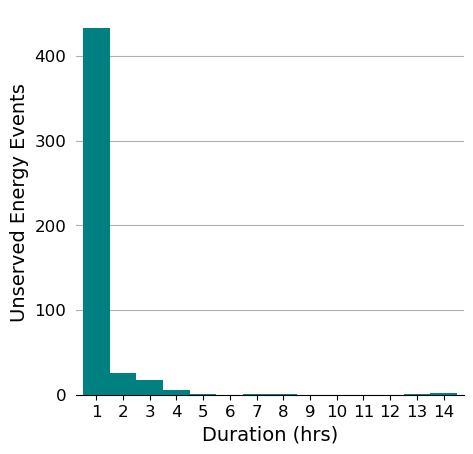

In [ ]:
def _plot_LOLE_distribution(ax, df_events_):
    print(df_events_['hours'].unique(), df_events_['hours'].sum())

    (n, bins, patches) = ax.hist(df_events_['hours'], bins = 14, range = (1, 15), zorder = 5, color = 'teal')
    print(n)
    print(bins)
    print(n.shape, bins.shape)

    ax.set_xlabel('Duration (hrs)', fontsize = 14)
    ax.set_ylabel('Unserved Energy Events', fontsize = 14)
    ax.set_xticks(np.arange(0, 15, 1) + 1.5)
    ax.set_xticklabels(bins.astype(int))

    ax.set_xlim(bins.min() - .25, bins.max() + .25)
    ax.set_ylim(0, )

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)

    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.grid(axis = 'y', zorder = 0)

fig, ax = plt.subplots(figsize = (5, 5))

_plot_LOLE_distribution(ax, df_events_)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Unserved energy distribution

In [ ]:
df_duration = df_load_.copy()
df_duration = df_duration[['timepoint','W','H','A','load_zone','unserved_energy','net_imports']]

df_unserved_energy = df_duration.copy()
df_unserved_energy= df_unserved_energy[['timepoint','W','H','A','load_zone','unserved_energy']]
# drop all the rows with unserved energy = 0
df_unserved_energy = df_unserved_energy[df_unserved_energy['unserved_energy'] > 0]
#sum unserved energy by timepoint for each load zone
df_unserved_energy = df_unserved_energy.groupby(['timepoint','W','H','A','load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# drop W,H,A columns
df_unserved_energy = df_unserved_energy.drop(columns=['W','H','A'])
#sum unserved energy for all load zones timepoint wise
df_unserved_energy = df_unserved_energy.groupby(['timepoint']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# arrane unserved energy in descending order
df_unserved_energy = df_unserved_energy.sort_values(by=['unserved_energy'], ascending=False).reset_index(drop = True)
print(df_unserved_energy.shape)

(203, 2)


In [ ]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])

# Load shedding greater than 1MW
tau = 1

df = df.loc[df['unserved_energy'] > tau].reset_index(drop = True)
print(df.shape)


(617, 6)


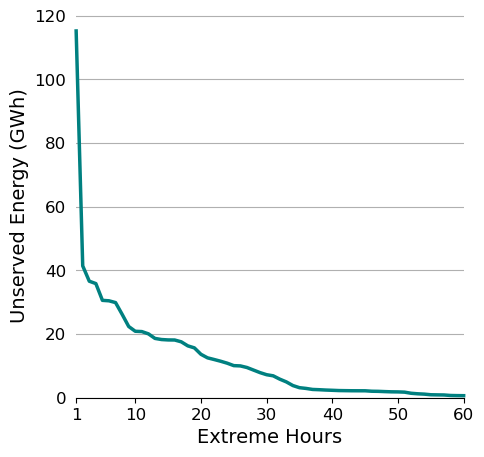

In [ ]:
def _plot_unsrved_energy_dist(ax, df, cutoff = 50):
    x_ = range(1, len(df) + 1)
    y_ = df['unserved_energy']/1e3
    ax.plot(x_[:cutoff], y_[:cutoff], lw = 2.5, clip_on = False, color = 'teal')
    ax.set_xlabel('Extreme Hours', fontsize = 14)
    ax.set_ylabel('Unserved Energy (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(1, cutoff)
    ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.set_xticks([1, 10, 20, 30, 40, 50, 60], [1, 10, 20, 30, 40, 50, 60])
    ax.grid(axis = 'y')

fig, ax = plt.subplots(figsize = (5, 5))

_plot_unsrved_energy_dist(ax, df_unserved_energy, cutoff = 60)

plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)
plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Net imports distribution

In [26]:
# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Karnataka'  # ← replace with the zone you want

# 1. filter out zeros and unwanted columns
df_zone = (df_duration.loc[df_duration['net_imports'] != 0, ['timepoint','load_zone','net_imports']])

# 2. keep only your zone
df_zone = df_zone[df_zone['load_zone'] == zone]

# 3. group by timepoint and sum
df_zone_import = (df_zone.groupby('timepoint', as_index=False)['net_imports'].sum())

# 4. sort if you like
df_zone_import = df_zone_import.sort_values('net_imports', ascending=False)

print(df_zone_import.head())

       timepoint    net_imports
7630  2041021223  306267.232082
7582  2041021023  300180.531043
7750  2041021723  294933.909671
8062  2041030223  292925.035558
6766  2041010723  291851.189006


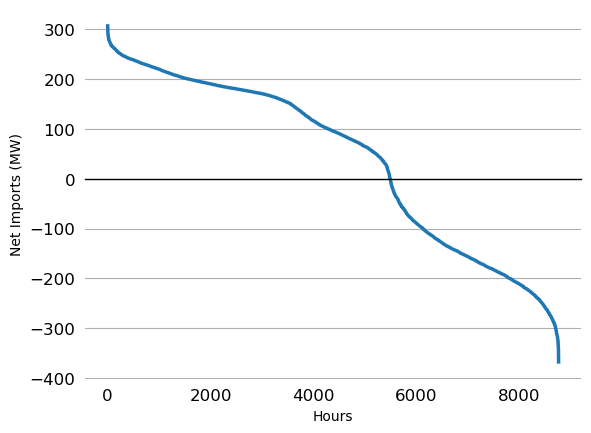

In [27]:
def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports']/1e3

    ax.plot(x_, y_, lw = 2.5)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Net Imports (MW)')
    # ax.title('Distribution of Unserved Energy')
    # ax.set_xlim(0.9,50)
    # ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    # ax.set_xticks([1, 10, 20, 30, 40, 50], [1, 10, 20, 30, 40, 50])
    ax.grid(axis = 'y')
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False)

fig = plt.figure()
ax = fig.add_subplot(111)

plot_net_import_dist(ax, df_zone_import)

# Load and processing project timepoints

In [ ]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw']] # availability_derate
               
                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh'})
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone']).agg({'power_mw': 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

# Undergeneration and overgeneration heatmap

In [194]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

In [195]:
df_overgen = df_dispatch_.copy()
df_overgen = df_overgen[['timestamp','load_zone','curtailment_mw']]
df_overgen = df_overgen.groupby(['timestamp']).agg({'curtailment_mw': 'mean'}).reset_index(drop = False)

df_load_shedding = df_load_.copy()
df_load_shedding = df_load_shedding[['timestamp','load_zone','unserved_energy']]
df_load_shedding = df_load_shedding.groupby(['timestamp']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df_overgen_final = pd.merge(df_overgen, df_load_shedding, on = 'timestamp', how = 'outer')
df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

In [ ]:
# df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

# # Extract month and hour
# df_overgen_final['month'] = df_overgen_final['timestamp'].dt.month
# df_overgen_final['hour']  = df_overgen_final['timestamp'].dt.hour + 1  # to get 1–24

# # Build pivot table: sum of residuals by hour (rows) and month (columns)
# pivot_table = df_overgen_final.pivot_table(
#     values='residual',
#     index='hour',
#     columns='month',
#     aggfunc='sum'
# )


# # Determine max absolute residual for symmetric color scaling
# max_abs = np.abs(pivot_table.values).max()

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(
#     pivot_table,
#     cmap='RdBu_r',    # reversed so negatives = red, positives = blue
#     center=0,         # zero maps to white
#     vmin=-max_abs,    # symmetric around zero
#     vmax= max_abs,
#     annot=False,
#     fmt=".1f"
# )

# # Labels and titles
# plt.xlabel('Month', fontsize=14)
# plt.ylabel('Hour of the Day', fontsize=14)
# plt.title('Heatmap of Residual (Curtailment − Unserved Energy)', fontsize=16)

# # Set month abbreviations on x-axis
# plt.xticks(
#     ticks=np.arange(0.5, 12.5),
#     labels=[calendar.month_abbr[i] for i in range(1, 13)],
#     rotation=45
# )
# plt.yticks(fontsize = 10)

# plt.tight_layout()
# plt.show()

-17.275645426045443 114.39322055592524


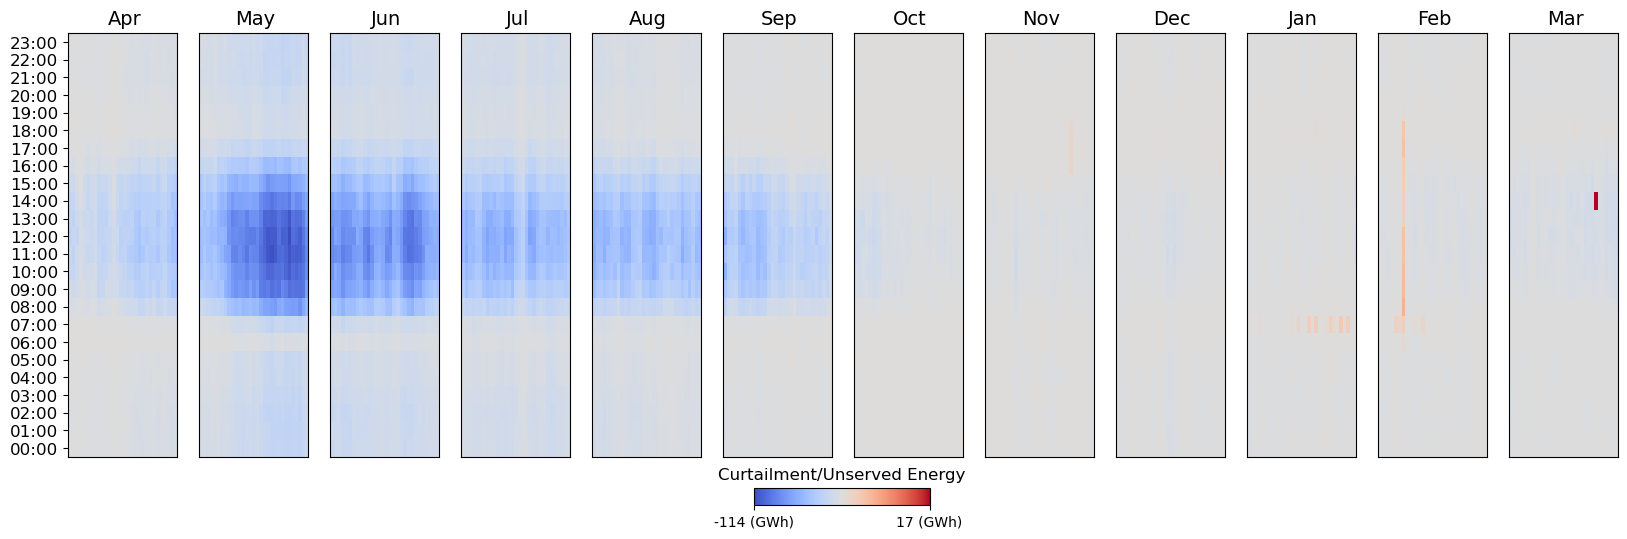

In [546]:
def _expected_unserved_energy(ax_, EUE_, EOE_): 

    units = 1e3

    N_years = 18
    N_hours = 24
    N_days  = 365

    month_days_     = np.array([0, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31])
    months_         = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
    cum_month_days_ = np.cumsum(month_days_)
    
    EUE_ = np.stack([EUE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EOE_ = np.stack([EOE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EUE_ = (EOE_ - EUE_)/units
    print(EUE_.min(), EUE_.max())

    idx_under_ = EUE_ > 0
    idx_over_  = EUE_ <= 0
    norm_EUE_ = np.zeros(EUE_.shape)

    norm_EUE_[idx_under_] = EUE_[idx_under_]/EUE_[idx_under_].max()
    norm_EUE_[idx_over_]  = -EUE_[idx_over_]/EUE_[idx_over_].min()

    hours_ = np.arange(datetime(2036, 1, 1, 0), datetime(2036, 1, 2, 0), timedelta(days = 1/24)).astype(datetime)
    hours_ = pd.to_datetime(hours_).strftime('%H:%M')

    _cmap = sns.color_palette("coolwarm", as_cmap=True)

    for i in range(12):
        ax_[i].imshow(norm_EUE_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      vmin          = -1.,
                      vmax          = 1,
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None')
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 14)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    ax_[0].set_yticks(np.linspace(0, 23, 24), hours_, fontsize = 12)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -3.25, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{-int(EUE_.max())} (GWh)', f'{-int(EUE_.min())} (GWh)'], size = 10)
    
    #cbar.ax.tick_params(length = 0)
    cbar.ax.set_title('Curtailment/Unserved Energy', rotation = 0, size = 12)
    

Shed_    = df_overgen_final['curtailment_mw'].to_numpy()
Curtail_ = df_overgen_final['unserved_energy'].to_numpy()

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

_expected_unserved_energy(ax_, Shed_, Curtail_)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.pdf', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show() 